PrimeTrade.ai Hiring Assignment
#                                   Data Analysis by Gunjan Ahuja

##1. Importing libraries

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [11]:
print("Libraries imported successfully!")

Libraries imported successfully!


 ## 2. Loading and understanding Datasets

In [14]:
fear_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")

In [15]:
print("Fear & Greed Dataset Shape :", fear_df.shape)
print("Historical Trades Shape   :", trades_df.shape)

Fear & Greed Dataset Shape : (2644, 4)
Historical Trades Shape   : (211224, 16)


In [16]:
display(fear_df.head())
display(trades_df.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


In [17]:
# Basic information about datasets

print("=" * 60)
print("Fear & Greed Dataset")
print("=" * 60)

fear_df.info()

print("\n")

print("=" * 60)
print("Historical Trades Dataset")
print("=" * 60)

trades_df.info()

Fear & Greed Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


Historical Trades Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-n

In [18]:
# Check missing values

print("Fear & Greed Missing Values")
display(fear_df.isnull().sum())

print("\n")

print("Historical Trades Missing Values")
display(trades_df.isnull().sum())

Fear & Greed Missing Values


,0
timestamp,0
value,0
classification,0
date,0




Historical Trades Missing Values


,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
print("Fear Dataset Date Range")
print("Start:", fear_df["date"].min())
print("End  :", fear_df["date"].max())

print()

print("Trades Dataset Date Range")
print("Start:", trades_df["Timestamp IST"].min())
print("End  :", trades_df["Timestamp IST"].max())

Fear Dataset Date Range
Start: 2018-02-01 00:00:00
End  : 2025-05-02 00:00:00

Trades Dataset Date Range
Start: 2023-05-01 01:06:00
End  : 2025-05-01 12:13:00


### Observations

- The Fear & Greed dataset contains **2,644 records** and **4 columns**.
- The Historical Trades dataset contains **211,224 records** and **16 columns**.
- Both datasets have **no missing values**, indicating they are complete and suitable for analysis.
- The `date` and `Timestamp IST` columns are currently stored as **object (string)** data types and will need to be converted into datetime format for time-based analysis.
- The Fear & Greed dataset spans from **1 February 2018** to **2 May 2025**.
- The Historical Trades dataset spans from **1 May 2023** to **1 May 2025**.
- The two datasets have a common time period between **May 2023 and May 2025**, making it possible to combine them for sentiment-based trading analysis.

## 3. Data Cleaning

In [19]:
# Check for duplicate rows

print("Fear & Greed Duplicate Rows :", fear_df.duplicated().sum())
print("Historical Trades Duplicate Rows :", trades_df.duplicated().sum())

Fear & Greed Duplicate Rows : 0
Historical Trades Duplicate Rows : 0


In [20]:
# Convert date columns to datetime format

fear_df["date"] = pd.to_datetime(fear_df["date"])
trades_df["Timestamp IST"] = pd.to_datetime(trades_df["Timestamp IST"],dayfirst=True)

In [21]:
fear_df.info()
print()

trades_df.info()
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side      

### Observations

- No duplicate rows were found in either dataset.
- Date columns were converted to `datetime64[ns]` to enable time-based analysis and merging.
- The datasets are now cleaned and ready for feature engineering and exploratory analysis.

## 4. Feature Engineering

In [23]:
# Extract useful features from trade timestamp

trades_df["Date"] = trades_df["Timestamp IST"].dt.date
trades_df["Year"] = trades_df["Timestamp IST"].dt.year
trades_df["Month"] = trades_df["Timestamp IST"].dt.month_name()
trades_df["Day"] = trades_df["Timestamp IST"].dt.day_name()
trades_df["Hour"] = trades_df["Timestamp IST"].dt.hour

In [24]:
trades_df[["Timestamp IST", "Date", "Year", "Month", "Day", "Hour"]].head()

,Timestamp IST,Date,Year,Month,Day,Hour
0,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
1,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
2,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
3,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
4,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22


In [28]:
fear_df["Date"] = fear_df["date"].dt.date
display(fear_df[["date", "Date"]].head())

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [29]:
sentiment_map = {
    "Extreme Fear": 0,
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}

fear_df["Sentiment_Score"] = fear_df["classification"].map(sentiment_map)
fear_df.head()

,timestamp,value,classification,date,Date,Sentiment Score,Sentiment_Score
0,1517463000,30,Fear,2018-02-01,2018-02-01,1,1
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02,0,0
2,1517635800,40,Fear,2018-02-03,2018-02-03,1,1
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04,0,0
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05,0,0


In [27]:
display(trades_df[["Timestamp IST", "Date", "Year", "Month", "Day", "Hour"]].head())

,Timestamp IST,Date,Year,Month,Day,Hour
0,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
1,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
2,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
3,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22
4,2024-12-02 22:50:00,2024-12-02,2024,December,Monday,22


## 5.Exploratory Data Analysis (EDA)

## 5.1 Historical Trades Analysis

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


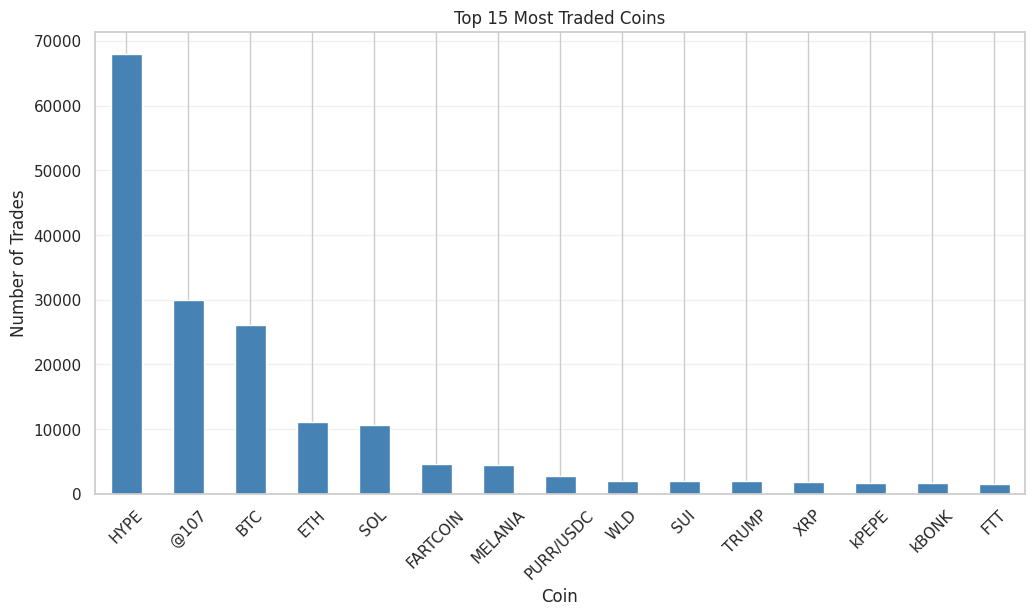

In [35]:
top_coins = trades_df["Coin"].value_counts().head(15)

display(top_coins)

plt.figure(figsize=(12,6))

top_coins.plot(kind="bar",color="steelblue")

plt.title("Top 15 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

,count
Side,
SELL,108528
BUY,102696


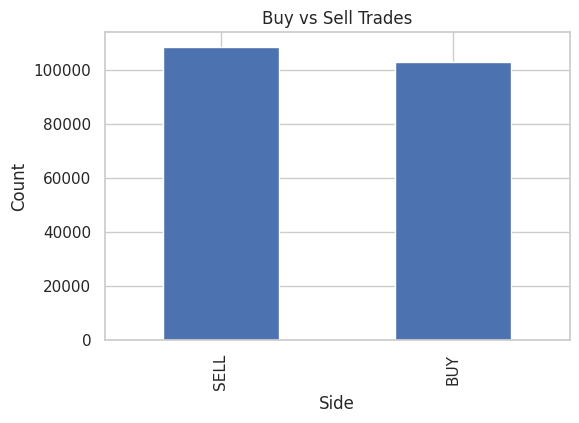

In [31]:
side_counts = trades_df["Side"].value_counts()

display(side_counts)

plt.figure(figsize=(6,4))
side_counts.plot(kind="bar")
plt.title("Buy vs Sell Trades")
plt.ylabel("Count")
plt.show()

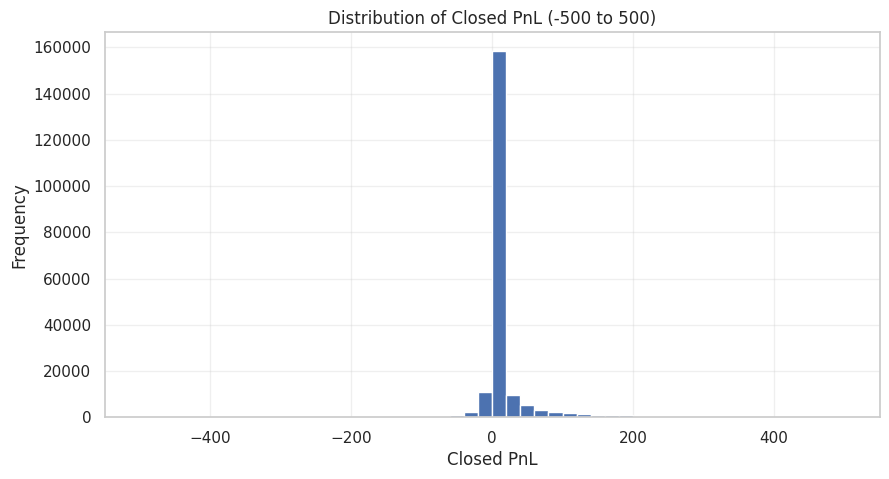

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    trades_df["Closed PnL"],
    bins=50,
    range=(-500,500)
)

plt.title("Distribution of Closed PnL (-500 to 500)")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [33]:
display(trades_df["Closed PnL"].describe())

,Closed PnL
count,211224.00
mean,48.75
std,919.16
min,-117990.10
25%,0.00
50%,0.00
75%,5.79
max,135329.09


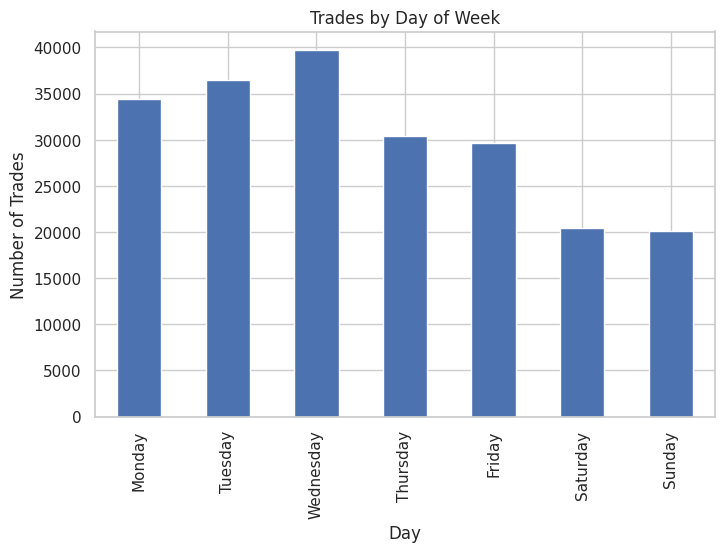

In [34]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = (
    trades_df["Day"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(8,5))

day_counts.plot(kind="bar")

plt.title("Trades by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trades")

plt.show()

### Observations

- The trading activity is highly concentrated in a few coins, with **HYPE** being the most traded asset, followed by **@107**, **BTC**, **ETH**, and **SOL**.
- The dataset contains an almost equal number of **BUY** and **SELL** trades, indicating balanced trading behaviour.
- Most trades have a **Closed PnL close to zero**, while only a few trades result in very large profits or losses.
- The median Closed PnL is **0**, suggesting that at least half of the trades closed with no profit or loss.
- Trading activity is highest during the **middle of the week**, peaking on **Wednesday**, while **Saturday** and **Sunday** have the lowest number of trades.

## 5.2 Fear & Greed Index Analysis

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


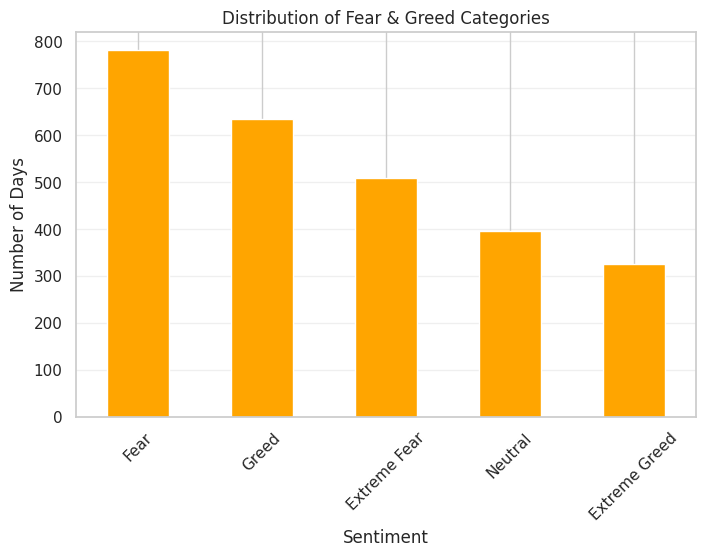

In [37]:
sentiment_counts = fear_df["classification"].value_counts()

display(sentiment_counts)

plt.figure(figsize=(8,5))

sentiment_counts.plot(kind="bar",color="orange")

plt.title("Distribution of Fear & Greed Categories")
plt.xlabel("Sentiment")
plt.ylabel("Number of Days")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

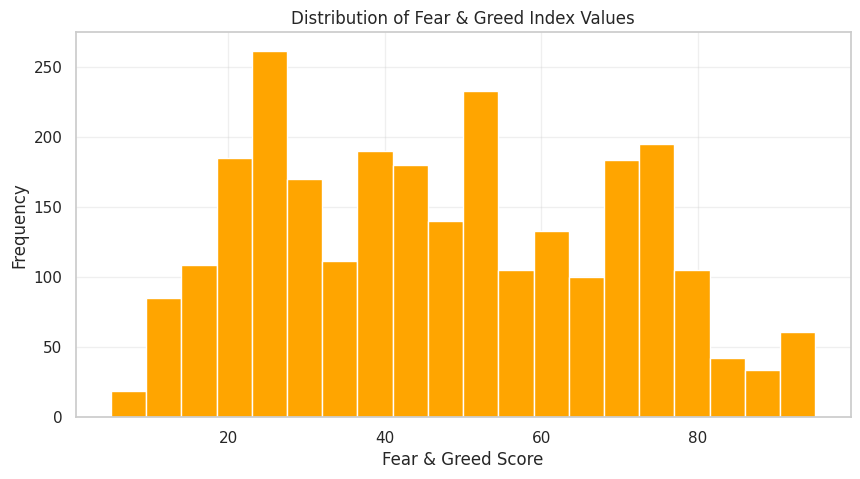

In [42]:
plt.figure(figsize=(10,5))

plt.hist(fear_df["value"],bins=20,color="orange")

plt.title("Distribution of Fear & Greed Index Values")

plt.xlabel("Fear & Greed Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.show()

In [39]:
display(fear_df["value"].describe())

,value
count,2644.00
mean,46.98
std,21.83
min,5.00
25%,28.00
50%,46.00
75%,66.00
max,95.00


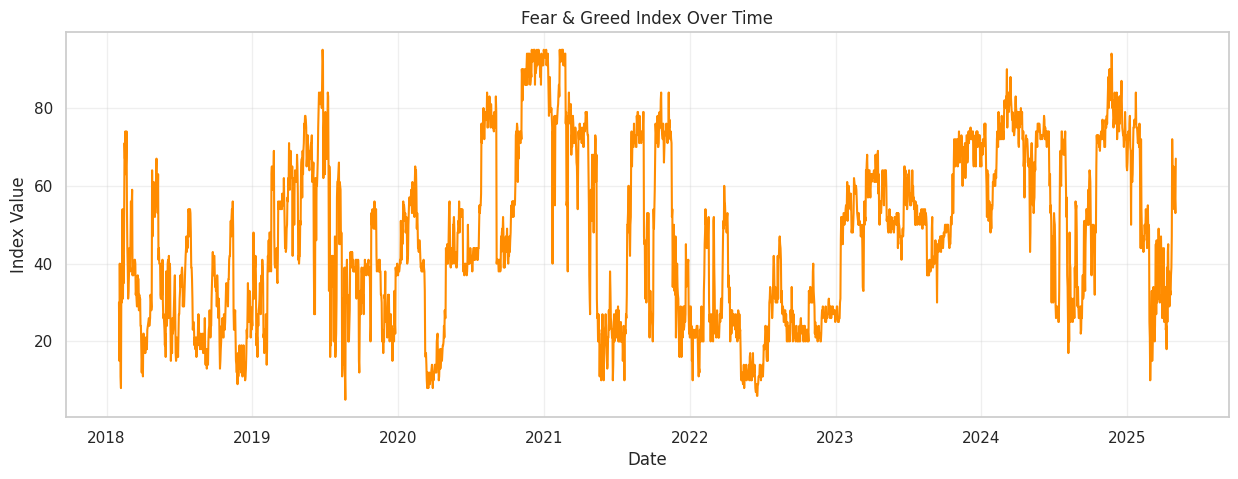

In [43]:
plt.figure(figsize=(15,5))

plt.plot(fear_df["date"],fear_df["value"],color="darkorange")

plt.title("Fear & Greed Index Over Time")

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.grid(alpha=0.3)
plt.show()

In [41]:
fear_df.groupby("classification")["value"].mean().sort_values()

,value
classification,
Extreme Fear,18.27
Fear,34.18
Neutral,49.96
Greed,65.85
Extreme Greed,82.12


### Observations

- The **Fear** category appears most frequently in the dataset, followed by **Greed**, while **Extreme Greed** occurs the least often.
- The Fear & Greed Index ranges from **5 to 95**, covering almost the entire sentiment spectrum from extreme fear to extreme greed.
- The average Fear & Greed score is **46.98**, which is close to the neutral range, indicating that the market sentiment remains balanced over the long term.
- The time series plot shows that market sentiment fluctuates significantly over time, moving repeatedly between fear and greed phases.
- The average index values increase consistently across the sentiment categories (Extreme Fear → Fear → Neutral → Greed → Extreme Greed), confirming that the dataset is correctly classified.

## 5.3 Merging the Datasets

In [44]:
# Convert trade timestamp to date only

trades_df["Date"] = pd.to_datetime(trades_df["Timestamp IST"]).dt.date
fear_df["Date"] = pd.to_datetime(fear_df["date"]).dt.date

In [45]:
merged_df = pd.merge(
    trades_df,
    fear_df[["Date","classification","value"]],
    on="Date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Year,Month,Day,Hour,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,2024-12-02 22:50:00,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,2024,December,Monday,22,Extreme Greed,80.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,2024-12-02 22:50:00,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,2024,December,Monday,22,Extreme Greed,80.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,2024,December,Monday,22,Extreme Greed,80.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,2024,December,Monday,22,Extreme Greed,80.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,2024-12-02 22:50:00,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,2024,December,Monday,22,Extreme Greed,80.00


In [49]:
print("Merged Dataset Shape :", merged_df.shape)
print()

print("Missing Sentiment Values")
print(merged_df[["classification","value"]].isnull().sum())

Merged Dataset Shape : (211224, 23)

Missing Sentiment Values
classification    6
value             6
dtype: int64


In [50]:
merged_df = merged_df.dropna()
print("New Shape :", merged_df.shape)

New Shape : (211218, 23)


In [47]:
display(

merged_df[
[
"Date",
"Coin",
"Side",
"Closed PnL",
"classification",
"value"
]
].head()

)

,Date,Coin,Side,Closed PnL,classification,value
0,2024-12-02,@107,BUY,0.00,Extreme Greed,80.00
1,2024-12-02,@107,BUY,0.00,Extreme Greed,80.00
2,2024-12-02,@107,BUY,0.00,Extreme Greed,80.00
3,2024-12-02,@107,BUY,0.00,Extreme Greed,80.00
4,2024-12-02,@107,BUY,0.00,Extreme Greed,80.00


### Observations

- The Historical Trades dataset was successfully merged with the Fear & Greed dataset using the trading date.
- The merged dataset contains 211,224 records and 23 columns.
- Only 6 records did not find a matching Fear & Greed value.
- These missing records represent less than 0.01% of the total dataset and can be safely removed.
- The merged dataset is now ready for sentiment-based trading analysis.

## 5.3.1 Average Closed PnL by Market Sentiment

,Closed PnL
classification,
Neutral,34.31
Extreme Fear,34.54
Greed,42.74
Fear,54.29
Extreme Greed,67.89


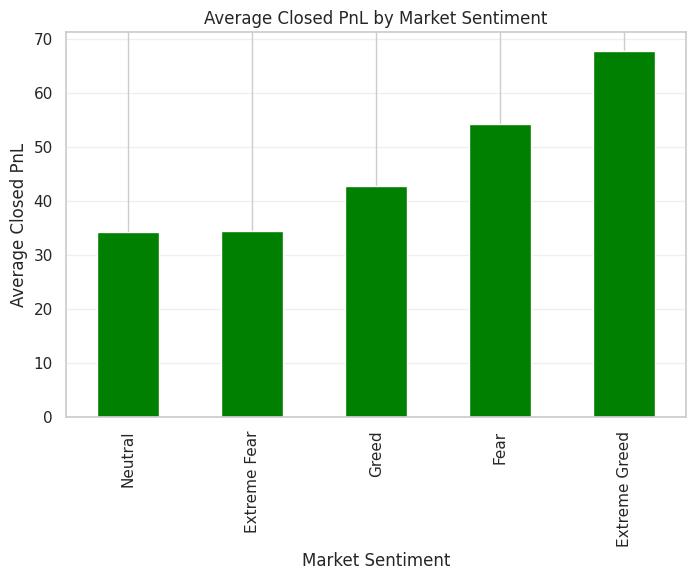

In [51]:
avg_pnl = merged_df.groupby("classification")["Closed PnL"].mean().sort_values()

display(avg_pnl)

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar", color="green")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Observations

- The highest average Closed PnL was observed during **Extreme Greed** (67.89).
- The lowest average Closed PnL occurred during **Neutral** market conditions (34.31).
- Average profit generally increases as market sentiment shifts from Fear towards Greed.
- This suggests that traders, on average, achieved better profitability during bullish market conditions.

## 5.3.2 Number of Trades under each Sentiment

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


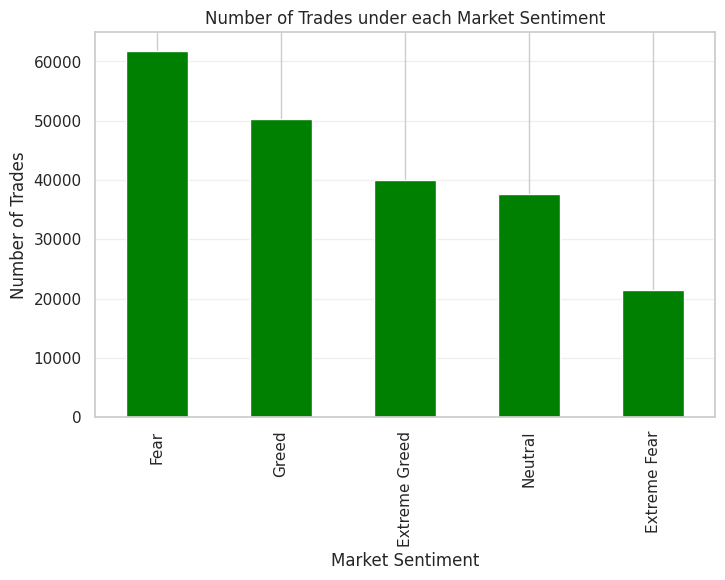

In [52]:
trade_counts = merged_df["classification"].value_counts()

display(trade_counts)

plt.figure(figsize=(8,5))

trade_counts.plot(kind="bar", color="green")

plt.title("Number of Trades under each Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- The largest number of trades occurred during **Fear** (61,837 trades).
- **Greed** was the second most active market condition with 50,303 trades.
- **Extreme Fear** had the lowest trading activity (21,400 trades).
- This indicates that trading activity tends to increase during Fear periods, possibly due to higher market volatility.

## 5.3.3 Average Trade Size (USD) by Sentiment

,Size USD
classification,
Extreme Greed,3112.25
Neutral,4782.73
Extreme Fear,5349.73
Greed,5736.88
Fear,7816.11


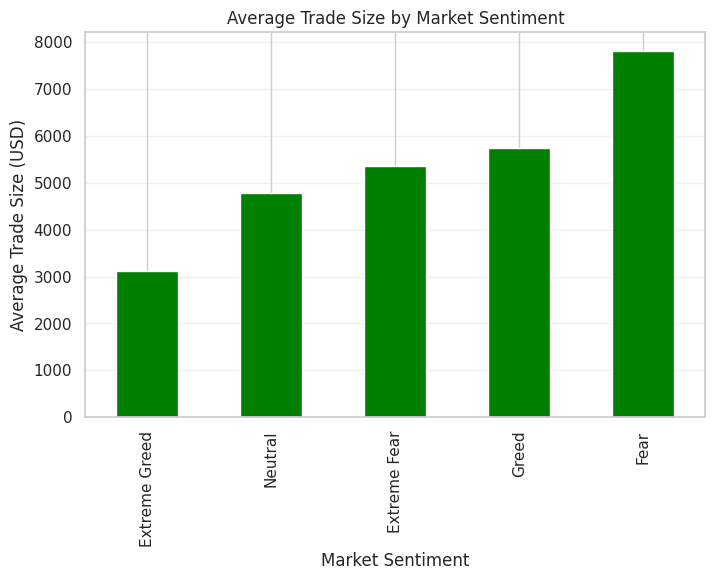

In [53]:
avg_size = merged_df.groupby("classification")["Size USD"].mean().sort_values()

display(avg_size)

plt.figure(figsize=(8,5))

avg_size.plot(kind="bar", color="green")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- The highest average trade size was recorded during **Fear** (7,816.11 USD).
- The smallest average trade size occurred during **Extreme Greed** (3,112.25 USD).
- Traders committed larger amounts of capital during Fear compared to Greed.
- This may indicate that traders opened larger positions during market uncertainty.

## 5.3.4 Buy vs Sell Distribution by Market Sentiment

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


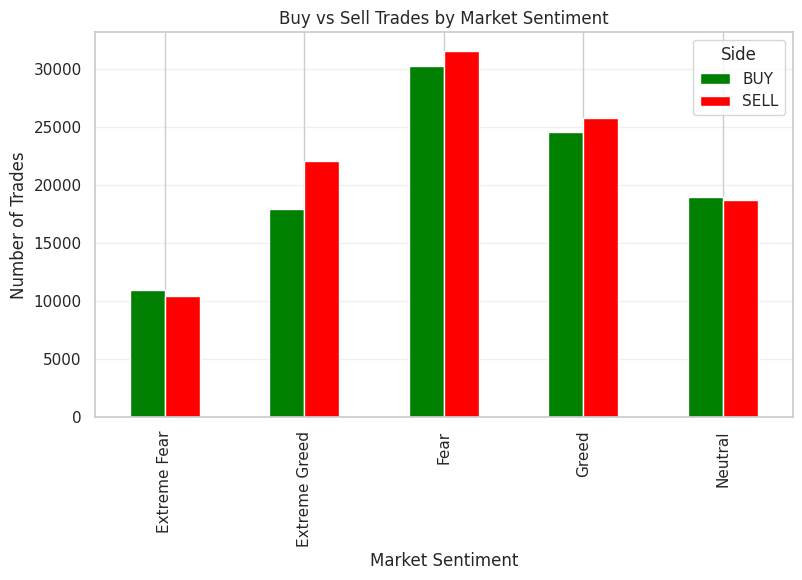

In [54]:
buy_sell = pd.crosstab(merged_df["classification"], merged_df["Side"])

display(buy_sell)

buy_sell.plot(
    kind="bar",
    figsize=(9,5),
    color=["green","red"]
)

plt.title("Buy vs Sell Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- Buy and Sell trades are relatively balanced across all market sentiments.
- Sell trades slightly exceed Buy trades during Fear, Greed, and Extreme Greed.
- During Extreme Fear, Buy trades are marginally higher than Sell trades.
- Overall, there is no significant imbalance between buying and selling behaviour across different market conditions.

## 5.3.5 Correlation Heatmap

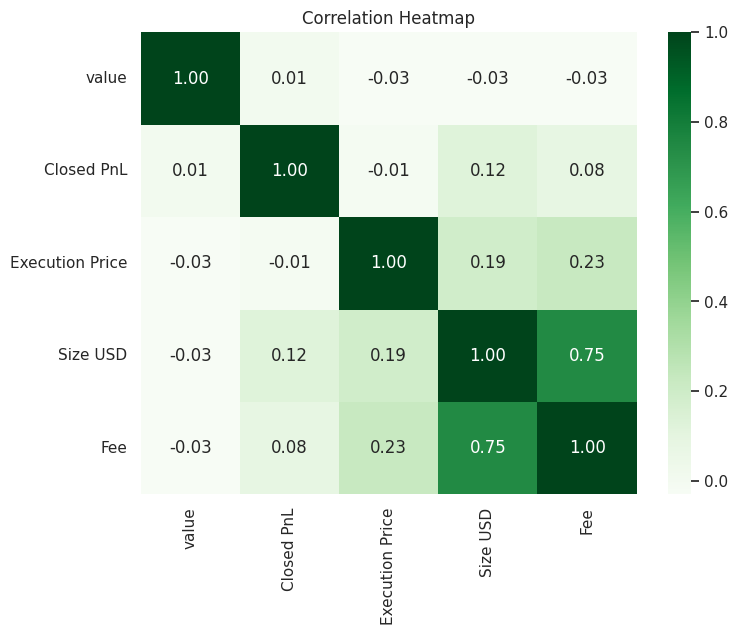

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(
    merged_df[
        ["value","Closed PnL","Execution Price","Size USD","Fee"]
    ].corr(),
    annot=True,
    cmap="Greens",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observations

- The strongest positive correlation is between **Size USD** and **Fee** (0.75), indicating that larger trades generally incur higher fees.
- Closed PnL has only a weak positive correlation with Size USD (0.12) and Fee (0.08).
- The Fear & Greed Index value shows almost no correlation with the selected trading variables.
- Overall, most variables exhibit weak correlations, suggesting that multiple factors influence trading performance.

# 6. Conclusion & Key Insights

### Key Findings

- The Historical Trades dataset contains over **211,000 trades**, while the Fear & Greed dataset contains **2,644 daily sentiment records**.

- Both datasets were clean, with no missing or duplicate values before merging.

- After merging on the trading date, only **6 records** could not be matched with a corresponding sentiment value and were removed.

- Trading activity was highest during **Fear** market conditions.

- The **highest average Closed PnL** was achieved during **Extreme Greed**.

- The **largest average trade size** occurred during **Fear**, suggesting traders allocated more capital during uncertain market conditions.

- Buy and Sell trades remained relatively balanced across all market sentiments.

- Correlation analysis showed that **trade size and trading fees** have the strongest positive relationship, while the Fear & Greed Index has only a weak direct correlation with individual trading metrics.

### Overall Conclusion

This analysis suggests that market sentiment influences trading behaviour in different ways. Fear periods are associated with higher trading activity and larger position sizes, whereas Extreme Greed is associated with higher average profitability. However, sentiment alone is not a strong predictor of trading performance, indicating that other market and trading factors also play an important role.

# Thank You

This notebook presents a complete exploratory analysis of historical cryptocurrency trades combined with the Fear & Greed Index. The workflow includes data understanding, cleaning, feature engineering, exploratory analysis, and sentiment-based insights.